In [104]:
import numpy as np
import h5py
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as settings

from utility.plot_from_hdf5 import plot_from_hdf5
from utility.plot_spectrum import plot_spectrum
from pipeline.processing.remove_spikes import remove_spikes
from pipeline.processing.fit_continuum import _powerlaw
from pipeline.processing.fit_gaussians import _gaussian, _two_gaussian
from pipeline.processing.scale_civ_to_nv import _civ_template
from pipeline.processing.parameters import CIV_FIT_WINDOW, LYA_NV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, CIV_CONTINUUM_WINDOWS, CIV_AIR, NV_AIR, LYA_AIR
from utility.my_colors import palette_dark


settings = {
        'font.size':16,
        # 'xtick.direction':'in', 
        # 'xtick.minor.visible':True,
        # 'xtick.top':True,
        # 'ytick.direction':'in', 
        # 'ytick.minor.visible':True,
        # 'ytick.right':True,
        # 'xtick.major.size':4.0,
        # 'xtick.minor.size':2.0,
        # 'ytick.major.size':4.0,
        # 'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings) 

RELEVANT_RESULTS_PATH = "data/relevant_results.csv"
FIT_PARAMS_PATH = "data/fit_params.csv"
DETAILS_PATH = "/home/leya/Code/Uni/desi-red-quasars/data/result_details.csv"
SPECTRA_PATH = "/home/leya/Code/Uni/desi-red-quasars/data/spectra.h5"

In [2]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186890 entries, 39628261600268308 to 39627768828270015
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   rew_civ                  186890 non-null  float64
 1   rew_nv                   186890 non-null  float64
 2   rew_lya                  186890 non-null  float64
 3   snr_1700A                186888 non-null  float64
 4   snr_civ                  186890 non-null  float64
 5   snr_nv                   186890 non-null  float64
 6   snr_lya                  186890 non-null  float64
 7   pixel_used_civ           186890 non-null  float64
 8   pixel_used_blue_end_lya  186890 non-null  float64
 9   continuum_redchi         186890 non-null  float64
 10  z                        186890 non-null  float64
 11  zerr                     186890 non-null  float64
 12  civ_1549_flux            186890 non-null  float64
 13  civ_1549_flux_ivar       186890 non-n

In [2]:
details_df = pd.read_csv(DETAILS_PATH,index_col="targetid",dtype={"targetid":"str"})

In [23]:
settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':6.0,
        'xtick.minor.size':4.0,
        'ytick.major.size':6.0,
        'ytick.minor.size':4.0,
        'legend.frameon':False,
    }

plt.rcParams.update(**settings)

In [18]:
# targetid = str(39627768828270015)
targetid = str(39627901502489216)

with h5py.File(SPECTRA_PATH, "r") as f:
    data = f[f"{targetid}"][()]
    
lam = data[0,:]
flux = data[1,:]
ivar = data[2,:]

flux_clean, _ = remove_spikes(lam, flux, ivar=ivar)

#-------------------------------------------------------------------------------------

cont_params = ast.literal_eval(details_df.loc[targetid,"continuum_fit_lya_nv"])["fit_params"]
cont_flux = _powerlaw(lam/1290,**cont_params)

#-------------------------------------------------------------------------------------

civ_params = ast.literal_eval(details_df.loc[targetid,"line_fit_civ"])
civ_integration_window = ast.literal_eval(details_df.loc[targetid,"measurements_civ"])["integration_window"]

if civ_params["accept_two"]:
    civ_profile = _two_gaussian(lam,civ_params["fit_params"]["amp_c"],civ_params["fit_params"]["cen_c"],civ_params["fit_params"]["sigma_c"],civ_params["fit_params"]["amp_w"],civ_params["fit_params"]["cen_w"],civ_params["fit_params"]["sigma_w"])
else:
    civ_profile = _gaussian(lam, civ_params["fit_params"]["amplitude"],civ_params["fit_params"]["center"],civ_params["fit_params"]["sigma"])

civ_cont_params = ast.literal_eval(details_df.loc[targetid,"continuum_fit_civ"])
civ_cont_profile = civ_cont_params["fit_params"]["amplitude"] * ((lam / 1700.0) ** civ_cont_params["fit_params"]["alpha"])

civ_profile += civ_cont_profile

civ_mask = (lam > civ_integration_window[0]) & (lam < civ_integration_window[1])
civ_lam = lam[civ_mask]
civ_profile = civ_profile[civ_mask]

#-------------------------------------------------------------------------------------

nv_params = ast.literal_eval(details_df.loc[targetid,"line_fit_nv"])
nv_integration_window = ast.literal_eval(details_df.loc[targetid,"measurements_nv"])["integration_window"]

nv_profile = _civ_template(lam, nv_params["fit_params"]["scale"], nv_params["fit_params"]["shift"], civ_params["fit_params"], civ_params["accept_two"])+cont_flux

nv_mask = (lam > nv_integration_window[0]) & (lam < nv_integration_window[1])
nv_lam = lam[nv_mask]
nv_profile = nv_profile[nv_mask]

#-------------------------------------------------------------------------------------

lya_params = ast.literal_eval(details_df.loc[targetid,"line_fit_lya"])
lya_integration_window = ast.literal_eval(details_df.loc[targetid,"measurements_lya"])["integration_window"]

if lya_params["accept_two"]:
    lya_profile = _two_gaussian(lam,lya_params["fit_params"]["amp_c"],lya_params["fit_params"]["cen_c"],lya_params["fit_params"]["sigma_c"],lya_params["fit_params"]["amp_w"],lya_params["fit_params"]["cen_w"],lya_params["fit_params"]["sigma_w"])+cont_flux
else:
    lya_profile = _gaussian(lam, lya_params["fit_params"]["amplitude"],lya_params["fit_params"]["center"],lya_params["fit_params"]["sigma"])+cont_flux

lya_mask = (lam > lya_integration_window[0]) & (lam < lya_integration_window[1])
lya_lam = lam[lya_mask]
lya_profile = lya_profile[lya_mask]

[]

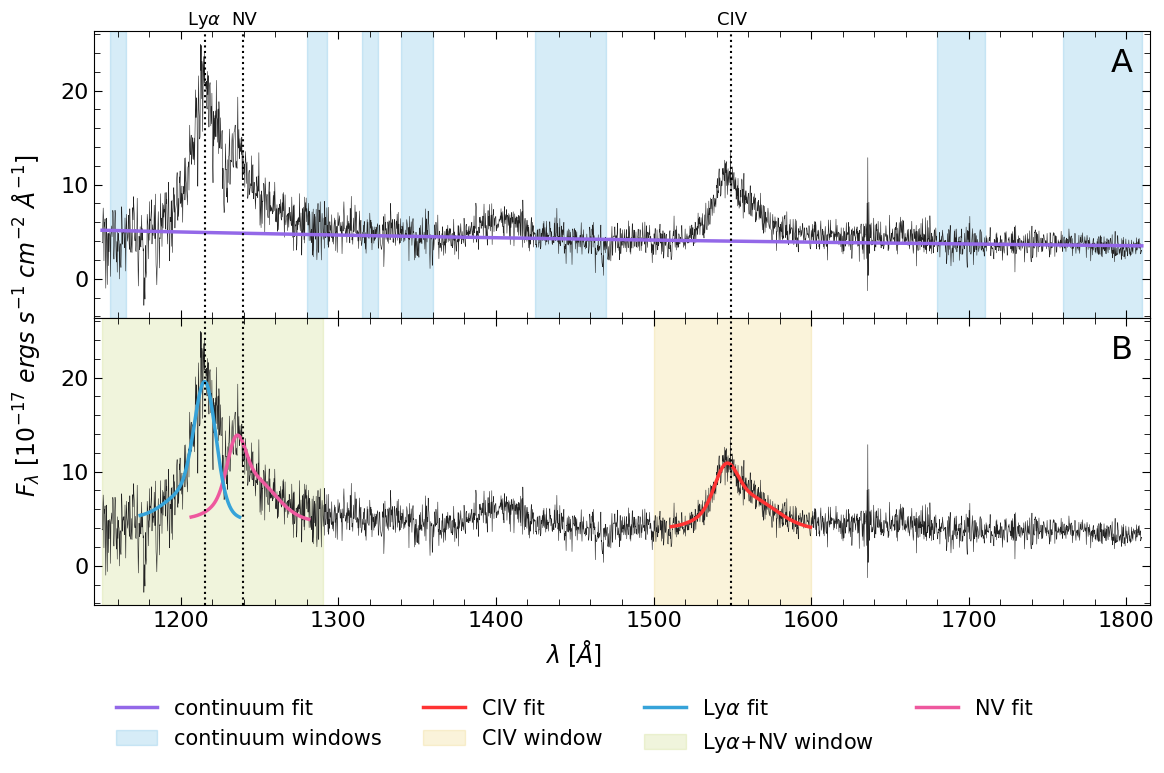

In [141]:
fig, ax = plt.subplots(2,1,figsize=(12,7),sharex=True,sharey="row")

# continuum stuff
ax[0].plot(lam,flux_clean,linewidth=0.4,color="#222222")
ax[0].plot(lam,cont_flux,linewidth=2.5,color=palette_dark[1],label="continuum fit")
for win in list(CIV_CONTINUUM_WINDOWS)+list(NV_LYA_CONTINUUM_WINDOWS):
    ax[0].axvspan(*win,alpha=0.2,color=palette_dark[2],label="continuum windows")

# line fit stuff
ax[1].plot(lam,flux_clean,linewidth=0.4,color="#222222")
ax[1].axvspan(*CIV_FIT_WINDOW,alpha=0.2,color=palette_dark[-2],label="CIV window")
ax[1].axvspan(*LYA_NV_FIT_WINDOW,alpha=0.2,color=palette_dark[-3],label=r"Ly$\alpha$+NV window")
ax[1].plot(lam[civ_mask],civ_profile,linewidth=2.5,label="CIV fit",color=palette_dark[-1])
ax[1].plot(lam[nv_mask],nv_profile,linewidth=2.5,label="NV fit",color=palette_dark[0])
ax[1].plot(lam[lya_mask],lya_profile,linewidth=2.5,label=r"Ly$\alpha$ fit",color=palette_dark[2])

# emission line lines and labels
ax[0].axvline(CIV_AIR,linestyle=":",color="black")
ax[1].axvline(CIV_AIR,linestyle=":",color="black")
ax[0].text(1540,27,"CIV",fontsize=13)
ax[0].axvline(NV_AIR,linestyle=":",color="black")
ax[1].axvline(NV_AIR,linestyle=":",color="black")
ax[0].text(1232,27,"NV",fontsize=13)
ax[0].axvline(LYA_AIR,linestyle=":",color="black")
ax[1].axvline(LYA_AIR,linestyle=":",color="black")
ax[0].text(1204,27,r"Ly$\alpha$",fontsize=13)

# A B
ax[0].text(1790,22,"A",fontsize=23)
ax[1].text(1790,22,"B",fontsize=23)

ax[0].set_xlim(1145,1815)

fig.supxlabel(r"$\lambda$ [$\AA$]",y=0.01,fontsize=17)
fig.supylabel(r"$F_{\lambda}~[10^{-17}~ergs~s^{-1}~cm^{-2}~{\AA}^{-1}]$",x=0.03,fontsize=17)


# legend shenanigans so the order is good 
handles1, labels1 = ax[0].get_legend_handles_labels()
handles = handles[:2]
labels = labels[:2]
handles_2, labels_2 = ax[1].get_legend_handles_labels()
handles.extend(handles_2)
labels.extend(labels_2)
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

leg = fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.14), 
    ncols=4,
    frameon=False,
    fontsize=15,
    markerscale=4
)


# remove whitespace between plots 
fig.subplots_adjust(
    left=0.1, right=0.98, bottom=0.1, top=0.92,
    wspace=0, hspace=0                             
)

# plt.savefig("images/window_plots.png")

plt.plot()

In [84]:
order = [0,1,4,2,6,3,5]

In [83]:
labels

['continuum fit',
 'continuum windows',
 'CIV window',
 'combinded Ly$\\alpha$ NV window',
 'CIV fit',
 'NV fit',
 'Ly$\\alpha$ fit']

In [7]:
plot_from_hdf5(targetid=targetid,df=details_df,smoothing_strength=1,CIV=True,NV=True,LYA=True,shaded_regions=[CIV_FIT_WINDOW,LYA_NV_FIT_WINDOW,*CIV_CONTINUUM_WINDOWS,*NV_LYA_CONTINUUM_WINDOWS],shaded_regions_colors=[palette_dark[-3],palette_dark[-2]]+[palette_dark[0]]*len(CIV_CONTINUUM_WINDOWS)+[palette_dark[2]]*len(NV_LYA_CONTINUUM_WINDOWS),shaded_regions_label=["CIV fit window","combined NV and Lya fit window"]+[""]*7,latex_font=False)

TypeError: _two_gaussian() got an unexpected keyword argument 'width_ratio'